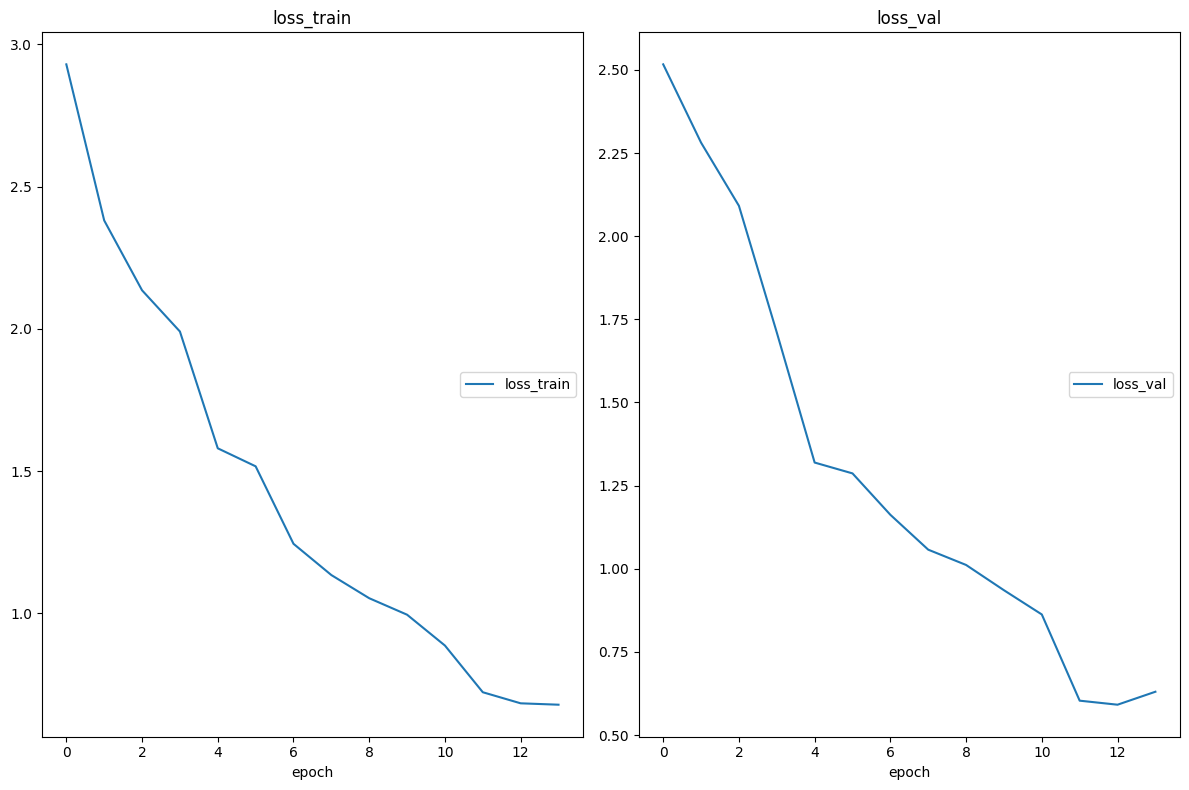

epoch:  70%|███████   | 14/20 [1:30:58<39:29, 394.92s/it]

loss_train
	loss_train       	 (min:    0.679, max:    2.930, cur:    0.679)
loss_val
	loss_val         	 (min:    0.591, max:    2.517, cur:    0.630)



loader:  19%|█▉        | 3/16 [00:57<04:07, 19.01s/it]

In [ ]:
"""
Notebook for exploring SSL training on coarsened hits with hit-level OT loss,
and event-level InfoNCE loss.
"""

"""
Imports

"""

import random
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import sys
import json
import h5py


import numpy as np
import torch
from torch.utils.data import IterableDataset, Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses
from torch_geometric.loader import DataLoader
import torch_cluster



sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import ColliderMLHits, ContrastiveLearningDataset, ContrastiveLearningGraphDataset, EventGraphBuilder
from src.data.coarsening import voxelize_hits
from src.data.graph_builder import EventGraphBuilder

from src.models.gnn import *
from src.models.contrastive_learning import My_Contrastive_Learning_01
from src.models.my_models import My_Model_01
from src.models.loss_functions import InfoNCE_Loss, EventWiseGeomOT_Loss



from torch.utils.tensorboard import SummaryWriter
import argparse
import torch.backends.cudnn as cudnn
from torchvision import models



model_names = sorted(name for name in models.__dict__
                     if name.islower() and not name.startswith("__")
                     and callable(models.__dict__[name]))

parser = argparse.ArgumentParser(description='ColliderML Training')


#parser.add_argument('-data', metavar='DIR', default='./datasets',help='path to dataset')

parser.add_argument('-dataset-name', default='colliderml',
                    help='dataset name')

parser.add_argument('-a', '--arch', metavar='ARCH', default='gnn',
                    help='model architecture: ')




parser.add_argument('--trainevents', default=640, type=int,
                    help='number of events used for training ')

parser.add_argument('--split', default='dihiggs-ttbar_scale_5.0_events_1500', help='dataset type')

parser.add_argument('--rotation', default=np.pi/8, help='scale for random global rotation')

parser.add_argument('--energy-noise', default=0.05, help='scale for (log)-energy noise')

parser.add_argument('--off', default=0, type=int, help='loading weights from previously trained model')





parser.add_argument('-j', '--workers', default=12, type=int, metavar='N',
                    help='number of data loading workers (default: 32)')

parser.add_argument('--epochs', default=20, type=int, metavar='N',
                    help='number of total epochs to run')


parser.add_argument('-b', '--batch-size', default=64, type=int,
                    metavar='N',
                    help='mini-batch size, this is the total '
                         'batch size of all GPUs on the current node when '
                         'using Data Parallel or Distributed Data Parallel')


parser.add_argument('--lr', '--learning-rate', default=0.001, type=float,
                    metavar='LR', help='initial learning rate', dest='lr')

parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
                    metavar='W', help='weight decay (default: 1e-4)',
                    dest='weight_decay')

parser.add_argument('--seed', default=42, type=int,
                    help='seed for initializing training. ')

parser.add_argument('--disable-cuda', action='store_true',
                    help='Disable CUDA')

parser.add_argument('--fp16-precision', action='store_true',
                    help='Whether or not to use 16-bit precision GPU training.')

parser.add_argument('--out_dim', default=32, type=int,
                    help='latent space dimension where constrastive loss is applied')

parser.add_argument('--feat_dim', default=4, type=int,
                    help='feature dimension')

parser.add_argument('--log-every-n-steps', default=100, type=int,
                    help='Log every n steps')

parser.add_argument('--temperature', default=0.07, type=float,
                    help='softmax temperature (default: 0.07)')

parser.add_argument('--n-views', default=2, type=int, metavar='N',
                    help='Number of views for contrastive learning training.')

parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')


args, unknown = parser.parse_known_args()

## save the args---done Later

assert args.n_views == 2, "Only two view training is supported. Please use --n-views 2."
    # check if gpu training is available
if not args.disable_cuda and torch.cuda.is_available():
    args.device = torch.device('cuda')
    torch.backends.cudnn.deterministic = True
    cudnn.benchmark = True    
else:
    args.device = torch.device('cpu')
    args.gpu_index = -1


    
# Fixing seed after parsing args
if args.seed is not None:
    SEED = args.seed

else:

    SEED = 42  # or any fixed integer


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)




"""
Loading ColliderML data

"""

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"]

## ggf data
cfg3 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ggf",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables3 = load_tables(cfg3)
frames3 = collect_tables(tables3)

calo_hits3 = frames3["calo_hits"]

import polars as pl

# Concatenate
#combined = pl.concat([calo_hits1, calo_hits2, calo_hits3])
combined = pl.concat([calo_hits1, calo_hits2])
#combined = pl.concat([calo_hits2, calo_hits3])

#combined = calo_hits2 #Only dihiggs

# Shuffle rows
combined = combined.sample(fraction=1.0, with_replacement=False, seed=SEED)

#print(combined.shape)
#print(combined.head())

calo_hits = combined



"""

Preparing dataset

"""


augment = Compose([
    RandomRotateXY(angle_range=(-args.rotation, args.rotation), gaussian = False),
    EnergyWhiteNoise(args.energy_noise),
    NoiseXYZ(5.0)
])




dataset_train = ColliderMLHits(calo_hits, split="train", shuffle_files=False, train_fraction=0.8, log=False)
dataset_val = ColliderMLHits(calo_hits, split="val", shuffle_files=False, train_fraction=0.8, log=False)

r = 0.0 # r does not matter for GravNetEncoder, but for GraphConvEncoder



MEANS = None
STDS = None





contrastive_dataset_train = ContrastiveLearningDataset(dataset_train, MEANS, STDS,  augment, voxel_size=100.0)

MEANS, STDS = contrastive_dataset_train.compute_mean_std(max_samples=50)

contrastive_dataset_val = ContrastiveLearningDataset(dataset_val, MEANS, STDS,  augment, voxel_size=100.0)


dataset_train = ContrastiveLearningGraphDataset(contrastive_dataset_train, builder=EventGraphBuilder(method='radius', radius=r, from_assignment=False, max_neighbors=14, knn_neighbor=0), cluster_voxel_size=264.0)

dataset_val = ContrastiveLearningGraphDataset(contrastive_dataset_val, builder=EventGraphBuilder(method='radius', radius=r, from_assignment=False, max_neighbors=14, knn_neighbor=0), cluster_voxel_size=264.0)



train_loader = DataLoader(dataset_train, batch_size=args.batch_size, drop_last=True)
val_loader   = DataLoader(dataset_val,   batch_size=args.batch_size, drop_last=True)



print("Data preprocessing working fine.")










"""
TRAIN THE MODEL

"""




"""
Specify the model
"""

#model = PointNetEncoder()

#model = GravNetEncoder(in_features=4, hidden_dim=16, latent_dim=64, proj_dim=32, k=8, space_dim=4, propagate_dim=16) # adjust the in_features properly, 2+1=3 for planar projections of hits

model = My_Model_01(input_dim=4, latent_dim=64, proj_dim=32, model_type="GravNetConv")


def count_trainable_parameters(mymodel):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_trainable_parameters(model))




"""
Specify the folder
"""

'''
folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(args.split, args.rotation, args.energy_noise)
    
os.makedirs(folder, exist_ok=True)
    
np.save(folder+'stats.npy',{'means': MEANS, 'stds': STDS, 'events': 544})



# Save the args
def serializable_args(args):
    return {k: str(v) if not isinstance(v, (int, float, str, bool, type(None))) else v
            for k, v in vars(args).items()}



json.dump(serializable_args(args), open(folder+'args.json', "w"), indent=4)
'''

# Load previous weights if needed

if args.off>0 :

    prev_weights = torch.load(folder+f'model_epoch_{args.off}.pth', map_location='cpu')   # add this)

    model.load_state_dict(prev_weights)




# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)




optimizer = torch.optim.Adam(model.parameters(), args.lr, weight_decay=args.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader), eta_min=0, last_epoch=-1)

#  It’s a no-op if the 'gpu_index' argument is a negative integer or None.



"""
Train the model
"""

with torch.cuda.device(args.gpu_index):

    
    info_nce_loss = InfoNCE_Loss(batch_size=args.batch_size, n_views=args.n_views, temperature=args.temperature)

    ot_loss = EventWiseGeomOT_Loss()

    loss_weights = [0.75,0.25]
    
    training = My_Contrastive_Learning_01(model=model, optimizer=optimizer, scheduler=scheduler, args=args, info_nce_loss=info_nce_loss, ot_loss=ot_loss, loss_weights=loss_weights)


      
    training.train(train_loader, val_loader, off=args.off, skip=1, save_model=False, folder = None, wandb_=False, key='', name='gravnet_models_{}_rot_{:.2f}_noise_{:.2f}'.format(args.split, args.rotation, args.energy_noise))

   